# 12-v3 — TCN Grid Search: Maker-Only Execution

## Lessons from v1 and v2

| Version | Execution | Trades | Win Rate | Return | Sharpe |
|---------|-----------|--------|----------|--------|--------|
| v1 | Close-only SL/TP, 0% fees, static params | 75 | 60.0% | +11.68% | 0.446 |
| v2 TBM static | TBM barriers (1×σ), intra-candle, 0.1% fees | 205 | 52.7% | **−34.00%** | −4.006 |
| v2 WFO | TBM barriers (1×σ), 5-ep warm-start, 0.1% fees | 933 | 46.9% | **−88.52%** | −10.703 |

**Root causes of v2 failure:**
1. TBM barriers at 1×σ ≈ 0.2–0.5% — any reversion within 12h triggers a round-trip, generating 2–12× more trades than v1
2. 0.1% flat taker on all entries and exits wiped the edge with that many trades
3. WFO 5-epoch warm-start destabilized the model — 933 trades vs 205 for static shows the fine-tuned model drifted into hyper-trading

## v3 fixes

| # | v2 (broken) | v3 (fixed) |
|---|------------------|-----------------|
| 1 | TBM barrier execution (2×205/933 tiny trades) | **ATR-relative SL/TP** — same as LGBM v5, fewer deeper trades |
| 2 | Market-order entry → 0.1% taker every trade | **Pullback limit entry** at `Close − entry_atr_mult × ATR` |
| 3 | Limit assumed filled on any wick touch | **5 bp penetration buffer** — FIFO queue guarantee |
| 4 | Flat 0.1% fee both sides | **Asymmetric**: Maker=0% (entries, TP) / Taker=0.05% × leverage (SL, time exits) |
| 5 | Funding rate ignored | **0.00077%/h × leverage** drag while in position |
| 6 | WFO 5-epoch warm-start → destabilized | **No WFO** — static production model; 5 epochs is too few to converge |

K-Fold fix from v2 is retained: fold-specific temporal internal validation (no global 2024 val_df look-ahead).

**Estimated runtime: ~30-90 min K-Fold (M4 MPS) + ~5 min grid search.**

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── K-Fold (fold-specific internal val — retained from v2) ───────────────
K                    = 5
EMBARGO              = 168
KFOLD_INTERNAL_VAL_H = 1500
EPOCHS_FOLD          = 60
PATIENCE_FOLD        = 10

# ── Execution model (v5-style, applied to TCN) ───────────────────────────
MAKER_FEE      = 0.0000   # 0%   — limit-order entries and TP exits
TAKER_FEE      = 0.0005   # 0.05% — SL, max-hold, conf exits
LEVERAGE       = 1.0
BUFFER         = 0.0005   # 5 bp wick-penetration for FIFO fill guarantee
FUNDING_RATE_H = 0.0000077  # 0.00077%/h ≈ 0.0062%/8h (MEXC empirical)

# ── Grid ─────────────────────────────────────────────────────────────────────
# TCN outputs 3-class probs; long/short thresholds apply to P(up) and P(down).
# 1/3 ≈ 0.333 = random baseline.  Grid spans just above baseline to high-conviction.
GRID = {
    'long_threshold':    [0.38, 0.42, 0.46, 0.50],
    'short_threshold':   [0.38, 0.42, 0.46, 0.50],
    'entry_atr_mult':    [0.2, 0.5, 0.8],
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [1.5, 2.0, 3.0],
    'min_sl':            [0.010, 0.015, 0.020],
    'min_hold':          [4, 8],
    'max_hold':          [24, 48],
    'cooldown':          [1, 2],
}

MIN_TRADES      = 15    # lower than LGBM: TCN has fewer signals
OPTIMISE_METRIC = 'sharpe'
TOP_N           = 20

# ── Model / data settings (must match notebook 11 / tcn_model.pt) ────────────
FRAC_D    = 0.4
FFD_THRES = 1e-4

TBM_VOL_WINDOW = 24
TBM_PT         = 1.0
TBM_SL         = 1.0
TBM_VERT_H     = 12
AUX_FWD_H      = 6
SEQ_LEN        = 24

TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.40

WARMUP_EPOCHS = 5
BATCH_SIZE    = 256
LR            = 2e-3
WEIGHT_DECAY  = 1e-3
LAMBDA_VOL    = 0.5
SEED          = 42

In [2]:
import itertools
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): DEVICE = torch.device('mps')
else:                            DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists(): REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT: {REPO_ROOT}  MODELS_DIR: {MODELS_DIR}')
print(f'Maker={MAKER_FEE*100:.2f}%  Taker={TAKER_FEE*100:.3f}%  '
      f'Buffer={BUFFER*1e4:.0f}bp  Funding={FUNDING_RATE_H*100:.5f}%/h')

Device: mps
REPO_ROOT: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system  MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
Maker=0.00%  Taker=0.050%  Buffer=5bp  Funding=0.00077%/h


In [3]:
# ── Features + high/low from raw parquet ─────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    BACKTEST_COLS = json.load(f)['backtest_only_cols']

selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

# ── FFD ───────────────────────────────────────────────────────────────────────
def _ffd_weights(d, thres=1e-4):
    w=[1.0]; k=1
    while True:
        w_k=-w[-1]/k*(d-k+1)
        if abs(w_k)<thres: break
        w.append(w_k); k+=1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights=_ffd_weights(d,thres); width=len(weights)
    vals=series.values.astype(np.float64); out=np.full(len(vals),np.nan)
    for i in range(width-1,len(vals)): out[i]=np.dot(weights,vals[i-width+1:i+1])
    return pd.Series(out,index=series.index)

log_close      = np.log(feat_df['close'])
fracdiff_close = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)
feat_df['fracdiff_close'] = fracdiff_close

# ── TBM labels (used for K-Fold model training only) ─────────────────────────
log_rets    = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
feat_df['rolling_vol'] = rolling_vol
close_vals = feat_df['close'].values
high_vals  = feat_df['high'].values
low_vals   = feat_df['low'].values
vol_vals   = rolling_vol.values
n          = len(close_vals)
tbm_labels = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0: continue
    entry = close_vals[i]
    upper = entry * (1 + TBM_PT * vol_vals[i]); lower = entry * (1 - TBM_SL * vol_vals[i])
    lbl = 2
    for j in range(1, TBM_VERT_H + 1):
        hi = high_vals[i+j]; lo = low_vals[i+j]
        if lo <= lower and hi >= upper: lbl=0; break
        elif lo <= lower:               lbl=0; break
        elif hi >= upper:               lbl=1; break
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# ── Aux vol + sample weights ──────────────────────────────────────────────────
fwd_vol = pd.concat([log_rets.shift(-h) for h in range(1, AUX_FWD_H+1)], axis=1).std(axis=1)
feat_df['fwd_vol'] = fwd_vol
w_raw = rolling_vol.fillna(rolling_vol.median()) / rolling_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

# ── Split ─────────────────────────────────────────────────────────────────────
ALL_INPUT_FEATS = selected_features + ['fracdiff_close']
required_cols   = ALL_INPUT_FEATS + ['tbm_label','fwd_vol','sample_weight',
                                      'rolling_vol','high','low'] + BACKTEST_COLS
clean_df        = feat_df[required_cols].dropna()

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Input features: {len(ALL_INPUT_FEATS)}')

Train:  56,949  2017-11-27 → 2024-06-01
Val:     3,888  2024-06-01 → 2024-11-10
Test:   13,236  2024-11-10 → 2026-05-15
Input features: 51


In [4]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel-1)*dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:,:,:-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch,out_ch,1) if in_ch!=out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x)+res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch,ch,kernel,2**i,dropout)); in_ch=ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,32), nn.GELU(),
            nn.Dropout(dropout*.5), nn.Linear(32,3))
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,16), nn.GELU(), nn.Linear(16,1), nn.Softplus())
    def forward(self, x):
        out = self.tcn(x.transpose(1,2)); last = out[:,:,-1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

n_params = sum(p.numel() for p in TCNMultiTask(
    len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
print(f'TCNMultiTask: {n_params:,} parameters')

def make_lr_lambda(total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup: return (epoch+1)/warmup
        progress = (epoch-warmup)/max(1,total_epochs-warmup)
        return 0.5*(1+math.cos(math.pi*progress))
    return lr_lambda

TCNMultiTask: 103,652 parameters


In [5]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt.fit(train_df[ALL_INPUT_FEATS].values)
print(f'QT fitted on train_df: {train_df[ALL_INPUT_FEATS].shape}')

X_train_qt  = qt.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)
y_train_all = train_df['tbm_label'].values.astype(np.int64)
w_train_all = train_df['sample_weight'].values.astype(np.float32)
v_train_all = train_df['fwd_vol'].values.astype(np.float32)

# Backtest arrays for grid search on OOS period
train_close = train_df['close'].values.astype(np.float64)
train_high  = train_df['high'].values.astype(np.float64)
train_low   = train_df['low'].values.astype(np.float64)
train_atr   = train_df['atr_14_pct'].values.astype(np.float64)
train_index = train_df.index

N_TRAIN = len(train_df)
print(f'N_TRAIN={N_TRAIN:,}  X_train_qt: {X_train_qt.shape}')

QT fitted on train_df: (56949, 51)
N_TRAIN=56,949  X_train_qt: (56949, 51)


## Phase 1 — Purged K-Fold with Fold-Specific Internal Validation

Retained from v2: internal val window is `[emb_start − KFOLD_INTERNAL_VAL_H, emb_start)` per fold
(pre-fold temporal region), not the global 2024 `val_df`. Fold 1 falls back to post-embargo.

In [6]:
oos_up   = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_down = np.full(N_TRAIN, np.nan, dtype=np.float32)
fold_size = N_TRAIN // K
print(f'K={K}  fold_size≈{fold_size:,}  EMBARGO={EMBARGO}  INT_VAL={KFOLD_INTERNAL_VAL_H}')

for k in range(K):
    print(f'\n{"="*60}')
    fold_start = k * fold_size
    fold_end   = (k+1)*fold_size if k < K-1 else N_TRAIN
    emb_start  = max(0,       fold_start-EMBARGO)
    emb_end    = min(N_TRAIN, fold_end  +EMBARGO)
    print(f'Fold {k+1}/{K}: rows [{fold_start},{fold_end})  embargo [{emb_start},{emb_end})')

    # Fold-specific internal val (v2 fix)
    if emb_start >= KFOLD_INTERNAL_VAL_H:
        int_end   = emb_start
        int_start = max(SEQ_LEN, emb_start - KFOLD_INTERNAL_VAL_H)
        int_src   = f'pre-fold [{int_start},{int_end})'
    else:
        int_start = max(SEQ_LEN, emb_end)
        int_end   = min(N_TRAIN, int_start + KFOLD_INTERNAL_VAL_H)
        int_src   = f'post-emb [{int_start},{int_end})'
    n_int = int_end - int_start
    print(f'  Int val: {int_src} ({n_int} rows)')

    # Build internal val sequences
    ctx_s = int_start - (SEQ_LEN-1)
    X_int_ctx = X_train_qt[max(0,ctx_s):int_end]
    off_int   = int_start - max(0,ctx_s)
    X_vl_seqs = []
    for i in range(off_int, len(X_int_ctx)):
        if i >= SEQ_LEN: X_vl_seqs.append(X_int_ctx[i-SEQ_LEN:i])
    if len(X_vl_seqs) == 0:
        print(f'  WARNING: no val seqs — skipping'); continue
    n_vl = len(X_vl_seqs)
    X_vl_fold = torch.from_numpy(np.array(X_vl_seqs, dtype=np.float32))
    y_vl_fold = torch.from_numpy(y_train_all[int_end-n_vl:int_end].copy())
    v_vl_fold = torch.from_numpy(v_train_all[int_end-n_vl:int_end].copy())
    print(f'  Val seqs: {n_vl:,}')

    # Training mask: exclude fold + embargo + internal val
    train_mask = np.ones(N_TRAIN, dtype=bool)
    train_mask[emb_start:emb_end] = False
    train_mask[int_start:int_end] = False
    train_indices = np.where(train_mask)[0]

    # Contiguous segments → sequences
    if len(train_indices) > 1:
        gaps = np.where(np.diff(train_indices) > 1)[0]
        seg_b = np.concatenate([[0], gaps+1, [len(train_indices)]])
    else:
        seg_b = np.array([0, len(train_indices)])

    X_fs, y_fs, w_fs, v_fs = [], [], [], []
    for ss, se in zip(seg_b[:-1], seg_b[1:]):
        seg_idx = train_indices[ss:se]
        if len(seg_idx) < SEQ_LEN: continue
        for i in range(SEQ_LEN-1, len(seg_idx)):
            win = seg_idx[i-SEQ_LEN+1:i+1]
            X_fs.append(X_train_qt[win])
            y_fs.append(y_train_all[seg_idx[i]])
            w_fs.append(w_train_all[seg_idx[i]])
            v_fs.append(v_train_all[seg_idx[i]])

    X_tr = torch.tensor(np.array(X_fs, dtype=np.float32))
    y_tr = torch.tensor(np.array(y_fs, dtype=np.int64))
    w_tr = torch.tensor(np.array(w_fs, dtype=np.float32))
    v_tr = torch.tensor(np.array(v_fs, dtype=np.float32))
    print(f'  Train seqs: {len(X_tr):,}')

    ccs = np.bincount(y_tr.numpy(), minlength=3).astype(np.float32)
    cw  = torch.tensor(ccs.sum()/(3*ccs+1e-8), dtype=torch.float32).to(DEVICE)

    model     = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=make_lr_lambda(EPOCHS_FOLD, WARMUP_EPOCHS))

    loader_tr = DataLoader(TensorDataset(X_tr, y_tr, w_tr, v_tr),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
    loader_vl = DataLoader(TensorDataset(X_vl_fold, y_vl_fold,
                                          torch.ones(len(y_vl_fold)), v_vl_fold),
                           batch_size=512, shuffle=False, num_workers=0)

    best_val = np.inf; pat = 0; best_state = None
    for epoch in range(EPOCHS_FOLD):
        model.train()
        for xb, yb, wb, vb in loader_tr:
            xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
            optimizer.zero_grad()
            lgts, vp = model(xb)
            loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
                   LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        scheduler.step()
        model.eval(); va = 0.0
        with torch.no_grad():
            for xb,yb,_,vb in loader_vl:
                xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
                lgts,vp  = model(xb)
                va += (F.cross_entropy(lgts,yb)+LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
        vl = va/max(len(loader_vl.dataset),1)
        if vl < best_val: best_val=vl; best_state={kk:vv.cpu().clone() for kk,vv in model.state_dict().items()}; pat=0
        else: pat+=1
        if pat >= PATIENCE_FOLD: print(f'  Early stop ep {epoch+1}  best_val={best_val:.5f}'); break
        if (epoch+1)%10==0: print(f'  Ep {epoch+1}/{EPOCHS_FOLD}  val={vl:.5f}  best={best_val:.5f}  pat={pat}')

    model.load_state_dict(best_state)

    # OOS inference
    lb_start = max(0, fold_start-(SEQ_LEN-1))
    X_ctx    = X_train_qt[lb_start:fold_end]
    offset   = fold_start - lb_start
    pred_seqs=[]; pred_pos=[]
    for i in range(offset, len(X_ctx)):
        if i >= SEQ_LEN: pred_seqs.append(X_ctx[i-SEQ_LEN:i]); pred_pos.append(lb_start+i)
    if not pred_seqs:
        model.cpu(); del model
        if DEVICE.type=='mps': torch.mps.empty_cache()
        continue
    model.eval(); ll=[]
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(
                torch.from_numpy(np.array(pred_seqs,dtype=np.float32))), batch_size=512):
            lgts,_ = model(xb.to(DEVICE)); ll.append(lgts.cpu())
    probs_fold = torch.softmax(torch.cat(ll),dim=1).numpy()
    for pos,pd_,pu in zip(pred_pos, probs_fold[:,0], probs_fold[:,1]):
        oos_down[pos]=pd_; oos_up[pos]=pu
    model.cpu(); del model
    if DEVICE.type=='mps': torch.mps.empty_cache()
    elif DEVICE.type=='cuda': torch.cuda.empty_cache()
    print(f'  Fold {k+1}/{K} done: {len(probs_fold):,} OOS preds')

valid_mask = ~np.isnan(oos_up)
print(f'\nOOS coverage: {valid_mask.sum():,}/{N_TRAIN:,} ({valid_mask.mean()*100:.1f}%)')

K=5  fold_size≈11,389  EMBARGO=168  INT_VAL=1500

Fold 1/5: rows [0,11389)  embargo [0,11557)
  Int val: post-emb [11557,13057) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,869
  Ep 10/60  val=0.70236  best=0.70236  pat=0
  Ep 20/60  val=0.70654  best=0.69765  pat=6
  Early stop ep 24  best_val=0.69765
  Fold 1/5 done: 11,365 OOS preds

Fold 2/5: rows [11389,22778)  embargo [11221,22946)
  Int val: pre-fold [9721,11221) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,678
  Ep 10/60  val=0.79554  best=0.74425  pat=2
  Early stop ep 18  best_val=0.74425
  Fold 2/5 done: 11,388 OOS preds

Fold 3/5: rows [22778,34167)  embargo [22610,34335)
  Int val: pre-fold [21110,22610) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,678
  Ep 10/60  val=0.83354  best=0.79130  pat=1
  Ep 20/60  val=0.83776  best=0.75647  pat=8
  Early stop ep 22  best_val=0.75647
  Fold 3/5 done: 11,388 OOS preds

Fold 4/5: rows [34167,45556)  embargo [33999,45724)
  Int val: pre-fold [32499,33999) (1500 rows)
  Val seq

OOS rows: 56,921  range: 2017-11-28 → 2024-06-01
P(up)   mean=0.4724  std=0.0748
P(down) mean=0.4902  std=0.0756


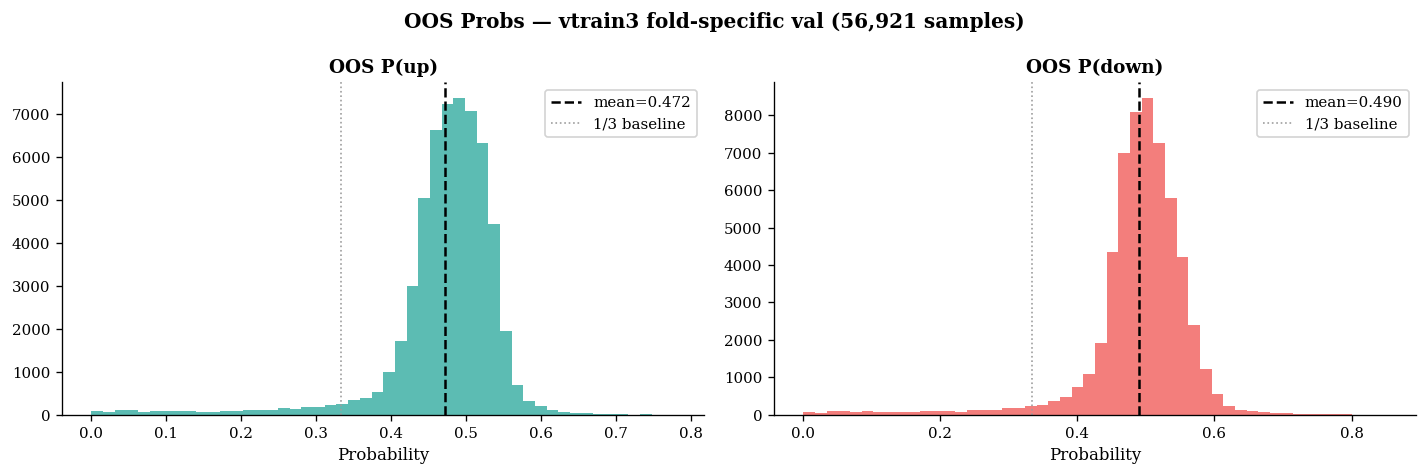

In [7]:
valid_mask  = ~np.isnan(oos_up)
oos_up_v    = oos_up[valid_mask]
oos_down_v  = oos_down[valid_mask]
oos_close_v = train_close[valid_mask]
oos_high_v  = train_high[valid_mask]
oos_low_v   = train_low[valid_mask]
oos_atr_v   = train_atr[valid_mask]
oos_index_v = train_index[valid_mask]
bh_oos      = oos_close_v / oos_close_v[0]

print(f'OOS rows: {len(oos_up_v):,}  range: {oos_index_v.min().date()} → {oos_index_v.max().date()}')
print(f'P(up)   mean={oos_up_v.mean():.4f}  std={oos_up_v.std():.4f}')
print(f'P(down) mean={oos_down_v.mean():.4f}  std={oos_down_v.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, prob, label, color in [
    (axes[0], oos_up_v,   'OOS P(up)',   GREEN),
    (axes[1], oos_down_v, 'OOS P(down)', RED),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5, label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3 baseline')
    ax.set_xlabel('Probability'); ax.legend()
    ax.set_title(label, fontweight='bold')
fig.suptitle(f'OOS Probs — v3 fold-specific val ({len(oos_up_v):,} samples)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_oos_prob_distribution_v3.png'); plt.show()

## Phase 2 — Grid Search: Maker-Only ATR Execution

Applied to OOS training-set probabilities (no test data touched).

**Key differences vs v2 TBM execution:**
- Entry: limit buy at `Close − entry_atr_mult × ATR` (pullback), fill check next bar with 5bp buffer
- SL/TP: `atr_multiplier × ATR[entry]` — wider than TBM barriers, fewer trades per signal
- Fees: Maker=0% (entries+TP), Taker=0.05% (SL+time exits) vs v2's flat 0.1% all sides
- Confidence exit: `P(up)` drops below `long_threshold − 0.10` (after min_hold)
- No WFO: 5-epoch warm-start proven to destabilize TCN (933 trades, −88% in v2)

In [8]:
def run_backtest_maker(
    probs_up, probs_down, close_arr, high_arr, low_arr, atr_arr,
    params,
    maker_fee=MAKER_FEE, taker_fee=TAKER_FEE, leverage=LEVERAGE,
    buf=BUFFER, fund_h=FUNDING_RATE_H
):
    """Maker-only entry, ATR SL/TP, asymmetric fees, funding drag."""
    lt       = params['long_threshold']
    st       = params['short_threshold']
    el       = max(0.28, lt - 0.10)   # confidence exit threshold (long)
    es       = max(0.28, st - 0.10)   # confidence exit threshold (short)
    ent_atr  = params['entry_atr_mult']
    sl_m     = params['sl_atr_multiplier']
    tp_m     = params['tp_atr_multiplier']
    min_sl   = params['min_sl']
    min_hold = int(params['min_hold'])
    max_hold = int(params['max_hold'])
    cd_n     = int(params['cooldown'])

    taker_eff = taker_fee * leverage
    maker_eff = maker_fee * leverage   # = 0.0
    fund_eff  = fund_h    * leverage

    cash=1.0; units=0.0; entry_cash=0.0
    in_pos=False; direction=None
    entry_px=0.0; dsl=0.0; dtp=0.0
    hold_count=0; cooldown=0; entry_bar=-1
    pending=None

    equity=[1.0]; trade_log=[]
    n_sig=0; n_fill=0; n_exp=0

    N = len(close_arr)
    for i in range(N):
        px=close_arr[i]; hi=high_arr[i]; lo=low_arr[i]
        p_up=probs_up[i]; p_dn=probs_down[i]; atr=atr_arr[i]
        if cooldown > 0: cooldown -= 1

        # ── 1. Fill check (TIF = 1 bar) ─────────────────────────────────────
        if pending is not None:
            lp = pending['limit_px']
            if pending['direction'] == 'long':
                if lo < lp * (1.0 - buf):
                    units=cash*(1.0-maker_eff)/lp; cash=0.0
                    in_pos=True; direction='long'; entry_px=lp
                    entry_bar=i; hold_count=0; dsl=pending['sl']; dtp=pending['tp']
                    n_fill += 1
                else: n_exp += 1
            else:
                if hi > lp * (1.0 + buf):
                    entry_cash=cash*(1.0-maker_eff); cash=0.0; units=entry_cash/lp
                    in_pos=True; direction='short'; entry_px=lp
                    entry_bar=i; hold_count=0; dsl=pending['sl']; dtp=pending['tp']
                    n_fill += 1
                else: n_exp += 1
            pending = None

        # ── 2. Manage position (not on entry bar) ────────────────────────────
        if in_pos and i > entry_bar:
            hold_count += 1
            if direction=='long': units      *= (1.0 - fund_eff)
            else:                 entry_cash *= (1.0 - fund_eff)

            reason=None; exit_px=px; pnl=0.0

            if direction == 'long':
                slp = entry_px*(1.0-dsl); tpp = entry_px*(1.0+dtp)
                tpc = tpp*(1.0+buf)   # TP wick must clear buffer
                sl_hit=lo<=slp; tp_hit=hi>tpc
                if sl_hit and tp_hit: reason='sl'; exit_px=slp
                elif sl_hit:          reason='sl'; exit_px=slp
                elif tp_hit:          reason='tp'; exit_px=tpp
                elif hold_count>=max_hold: reason='max_hold'
                elif hold_count>=min_hold and p_up<el: reason='conf'
                if reason:
                    pnl=(exit_px-entry_px)/entry_px
                    fe = taker_eff if reason!='tp' else maker_eff
                    cash=units*exit_px*(1.0-fe); units=0.0
            else:
                slp = entry_px*(1.0+dsl); tpp = entry_px*(1.0-dtp)
                tpc = tpp*(1.0-buf)   # TP wick must dip below tpp*(1-buf)
                sl_hit=hi>=slp; tp_hit=lo<tpc
                if sl_hit and tp_hit: reason='sl'; exit_px=slp
                elif sl_hit:          reason='sl'; exit_px=slp
                elif tp_hit:          reason='tp'; exit_px=tpp
                elif hold_count>=max_hold: reason='max_hold'
                elif hold_count>=min_hold and p_dn<es: reason='conf'
                if reason:
                    gross=(entry_px-exit_px)/entry_px; pnl=gross
                    fe = taker_eff if reason!='tp' else maker_eff
                    cash=entry_cash*(1.0+gross)*(1.0-fe)

            if reason:
                trade_log.append({'direction':direction,'pnl_pct':pnl,
                                   'hold_h':hold_count,'reason':reason})
                in_pos=False; hold_count=0; cooldown=cd_n

        # ── 3. Place pending order if flat ───────────────────────────────────
        if not in_pos and pending is None and cooldown==0:
            sl_v=max(sl_m*atr, min_sl); tp_v=tp_m*atr
            if p_up >= lt:
                pending={'direction':'long',  'limit_px':px-ent_atr*atr,'sl':sl_v,'tp':tp_v}; n_sig+=1
            elif p_dn >= st and p_up < lt:
                pending={'direction':'short', 'limit_px':px+ent_atr*atr,'sl':sl_v,'tp':tp_v}; n_sig+=1

        # ── Equity ───────────────────────────────────────────────────────────
        if in_pos and direction=='long':   equity.append(units*px)
        elif in_pos and direction=='short': equity.append(entry_cash*(1.0+(entry_px-px)/entry_px))
        else:                              equity.append(cash)

    if in_pos:
        px=close_arr[-1]
        if direction=='long':  gross=(px-entry_px)/entry_px; cash=units*px*(1-taker_eff)
        else: gross=(entry_px-px)/entry_px; cash=entry_cash*(1+gross)*(1-taker_eff)
        trade_log.append({'direction':direction,'pnl_pct':gross,'hold_h':hold_count,'reason':'eod'})
        equity[-1]=cash

    tdf=pd.DataFrame(trade_log)
    tdf.attrs={'n_signals':n_sig,'n_fills':n_fill,'n_expires':n_exp}
    return np.array(equity[1:]), tdf


def score_eq(eq, tdf, metric):
    if tdf.empty: return -np.inf
    r=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); ann=24*365
    if metric=='sharpe':       return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(ann))
    if metric=='total_return': return float(eq[-1]-1)
    if metric=='calmar':
        ar=float((eq[-1]**(ann/len(eq)))-1); pk=np.maximum.accumulate(eq)
        return ar/(abs(float(((eq-pk)/(pk+1e-12)).min()))+1e-6)
    if metric=='win_rate': return float((tdf['pnl_pct']>0).mean())
    return -np.inf

print(f'run_backtest_maker() defined.')

run_backtest_maker() defined.


In [9]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos):,}')

results = []
for vals in tqdm(combos, desc='Grid search (OOS maker)', ncols=80):
    p   = dict(zip(keys, vals))
    eq, tdf = run_backtest_maker(
        oos_up_v, oos_down_v, oos_close_v, oos_high_v, oos_low_v, oos_atr_v, p)
    if len(tdf) < MIN_TRADES: continue

    s  = score_eq(eq, tdf, OPTIMISE_METRIC)
    r  = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk = np.maximum.accumulate(eq)
    fr = tdf.attrs['n_fills']/max(tdf.attrs['n_signals'],1)

    results.append({
        **p,
        'score':        s,
        'total_return': float(eq[-1]-1),
        'sharpe':       float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365)),
        'max_dd':       float(((eq-pk)/(pk+1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct']>0).mean()),
        'n_long':       int((tdf['direction']=='long').sum()),
        'n_short':      int((tdf['direction']=='short').sum()),
        'n_sl':         int((tdf['reason']=='sl').sum()),
        'n_tp':         int((tdf['reason']=='tp').sum()),
        'fill_rate':    fr,
    })

results_df = pd.DataFrame(results).sort_values('score',ascending=False).reset_index(drop=True)
print(f'\nValid (≥{MIN_TRADES} trades): {len(results_df):,}/{len(combos):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}    : {results_df["score"].iloc[0]:.4f}')
    print(f'Fill rate     : mean={results_df["fill_rate"].mean():.1%}')

Grid combinations: 10,368


Grid search (OOS maker): 100%|████████████| 10368/10368 [05:12<00:00, 33.23it/s]


Valid (≥15 trades): 10,368/10,368
Best sharpe    : 0.1655
Fill rate     : mean=90.8%


In [10]:
from IPython.display import display

disp = ['score','total_return','sharpe','max_dd','win_rate','fill_rate',
        'n_trades','n_long','n_short','n_sl','n_tp',
        'long_threshold','short_threshold','entry_atr_mult',
        'sl_atr_multiplier','tp_atr_multiplier','min_sl','min_hold','max_hold','cooldown']
top = results_df[disp].head(TOP_N).copy()
for col,fmt in [('total_return','{:+.2%}'),('max_dd','{:.2%}'),('win_rate','{:.1%}'),
                ('fill_rate','{:.1%}'),('score','{:.4f}'),('sharpe','{:.3f}')]:
    top[col]=top[col].map(fmt.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  (TCN v3 maker execution):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k,v in best_params.items(): print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"OOS Trades":<24}: {int(best["n_trades"])}  (fill rate: {best["fill_rate"]:.1%})')

Top 20 by sharpe  (TCN vtrain3 maker execution):

     score total_return sharpe   max_dd win_rate fill_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  entry_atr_mult  sl_atr_multiplier  tp_atr_multiplier  min_sl  min_hold  max_hold  cooldown
0   0.1655     +104.94%  0.166  -91.39%    48.2%     91.1%      3770    2417     1353  1426  1044            0.46             0.42             0.8                1.5                3.0   0.020         4        24         1
1   0.1654     +104.87%  0.165  -91.39%    48.2%     91.1%      3770    2417     1353  1426  1044            0.46             0.42             0.5                1.5                3.0   0.020         4        24         1
2   0.1654     +104.79%  0.165  -91.40%    48.2%     91.1%      3770    2417     1353  1426  1044            0.46             0.42             0.2                1.5                3.0   0.020         4        24         1
3   0.1506      +92.01%  0.151  -90.80%    48.0%     90.9%

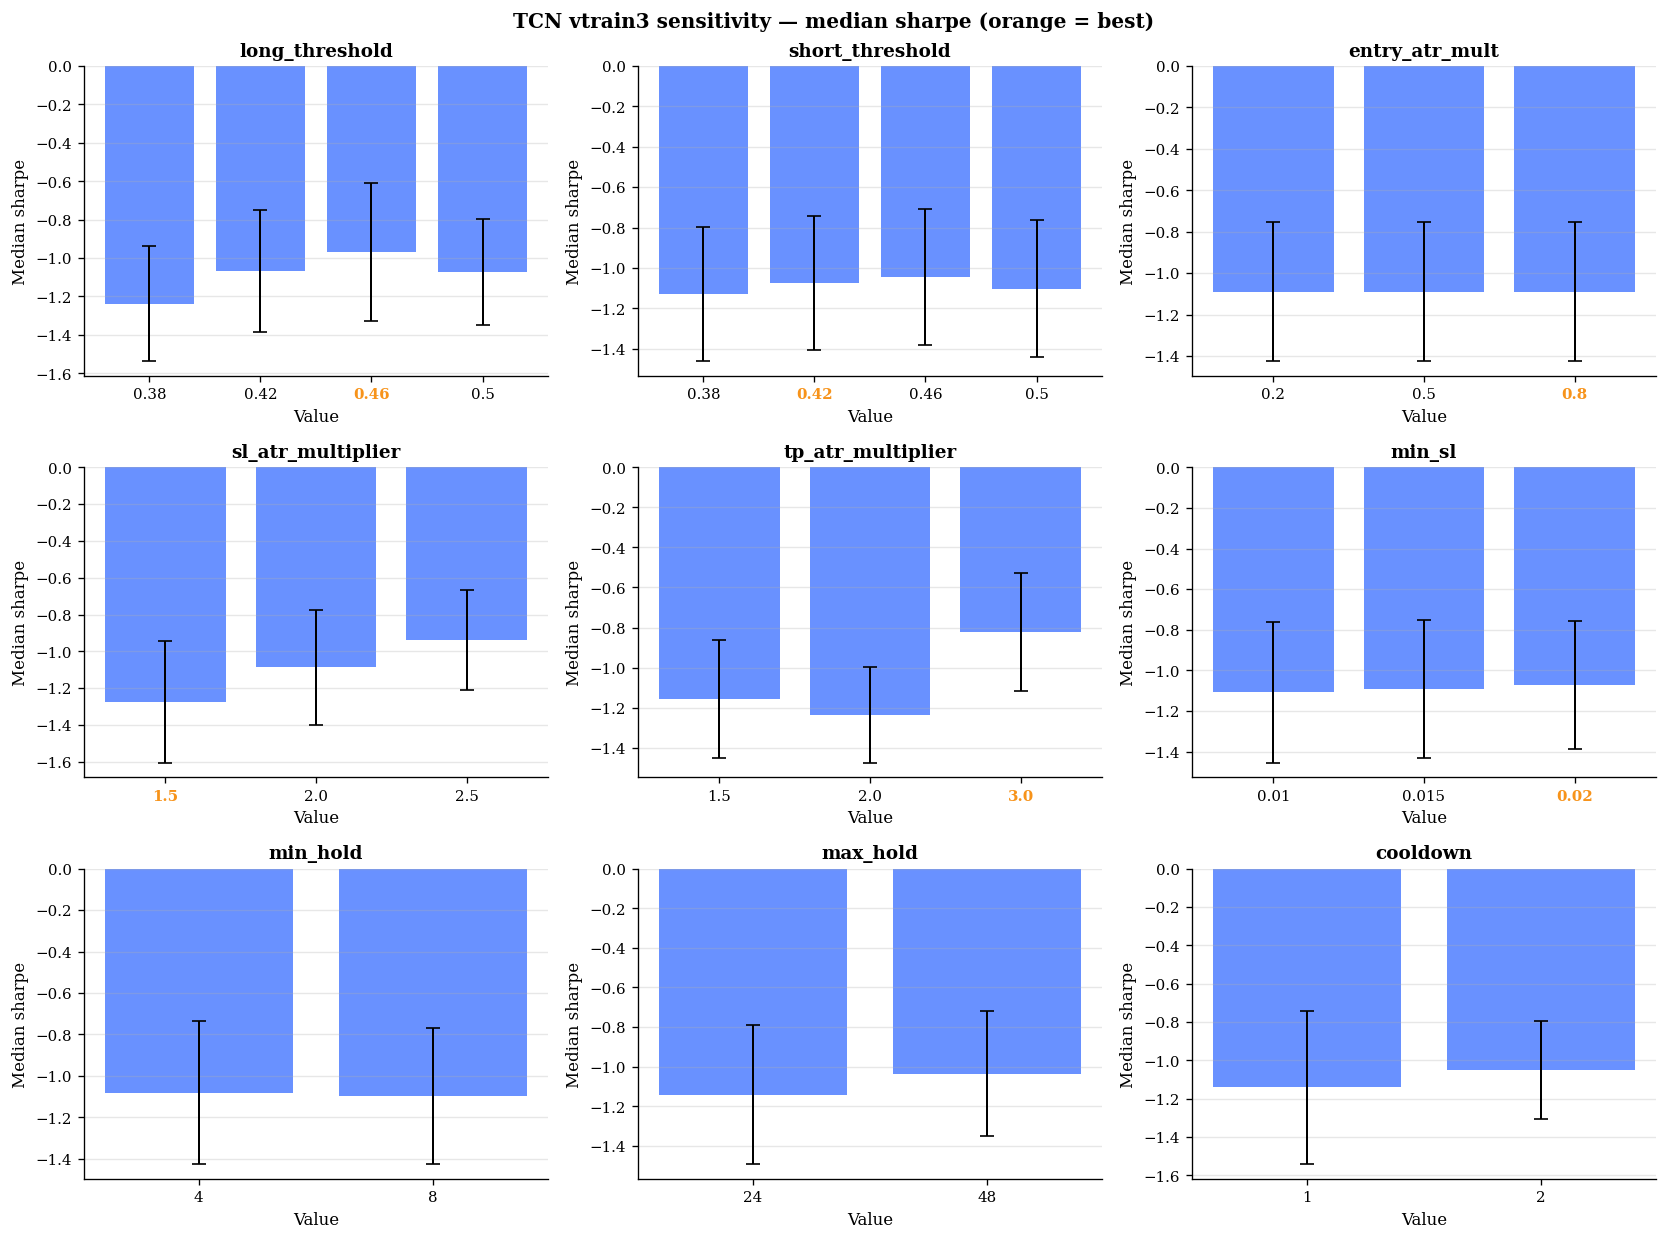

In [11]:
if not results_df.empty:
    n_p = len(keys); ncols=3; nrows=int(np.ceil(n_p/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3.5))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['score'].agg(['median','std']).reset_index()
        x   = grp[param].astype(str)
        ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
        ax.errorbar(x, grp['median'], yerr=grp['std'],
                    fmt='none', color='black', capsize=4, lw=1.2)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
        ax.grid(axis='y', alpha=0.3)
        bv = str(best[param])
        for tick in ax.get_xticklabels():
            if tick.get_text()==bv: tick.set_color(ACCENT); tick.set_fontweight('bold')
    for ax in axes.flat[n_p:]: ax.set_visible(False)
    fig.suptitle(f'TCN v3 sensitivity — median {OPTIMISE_METRIC} (orange = best)',
                 fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity_v3.png'); plt.show()

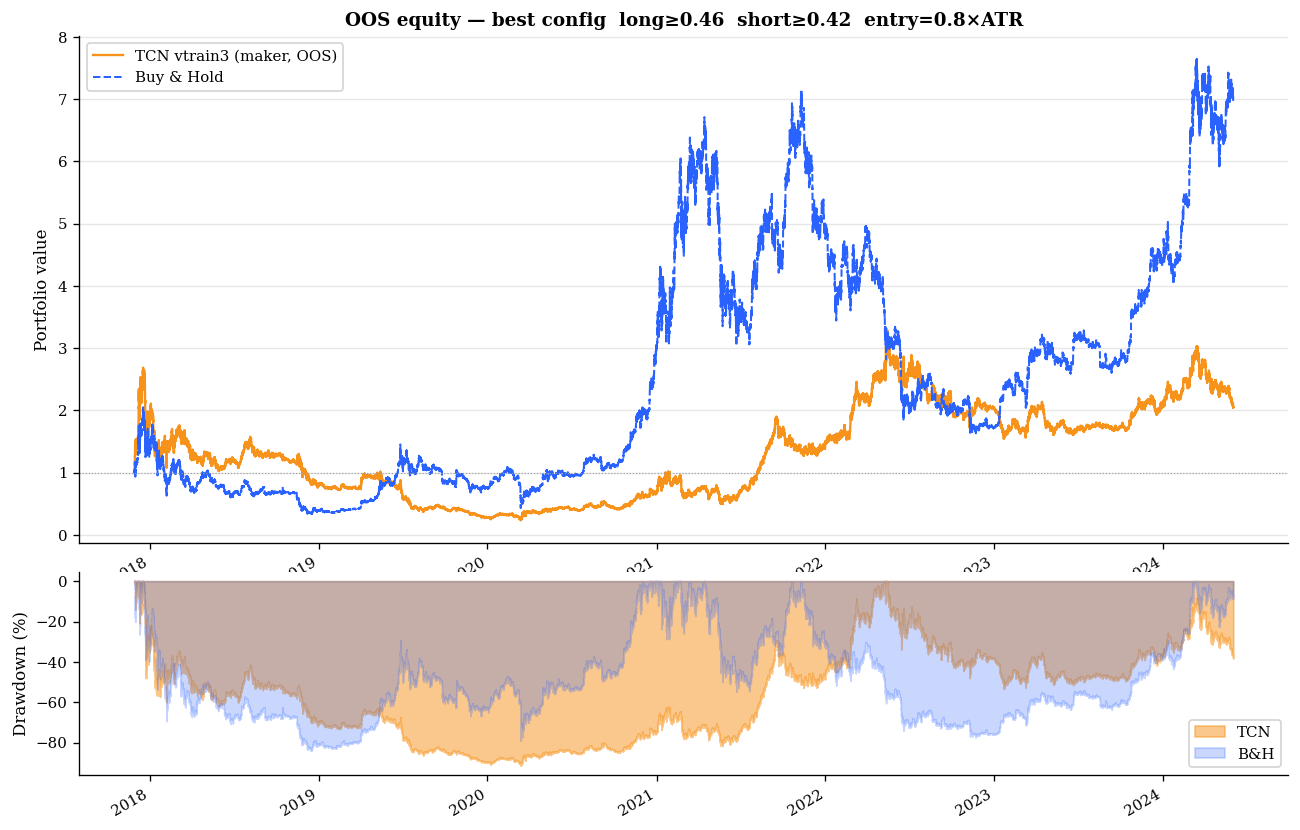

OOS  Sharpe=0.166  Return=+104.94%  MaxDD=-91.39%  Trades=3770  FillRate=91.1%


In [12]:
if not results_df.empty:
    eq_oos, tdf_oos = run_backtest_maker(
        oos_up_v, oos_down_v, oos_close_v, oos_high_v, oos_low_v, oos_atr_v, best_params)

    fig, axes = plt.subplots(2, 1, figsize=(13,8),
                              gridspec_kw={'height_ratios':[3,1.2],'hspace':0.08})
    ax=axes[0]
    ax.plot(oos_index_v, eq_oos, color=ACCENT, lw=1.4, label='TCN v3 (maker, OOS)')
    ax.plot(oos_index_v, bh_oos, color=BLUE, lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':'); ax.set_ylabel('Portfolio value')
    ax.set_title(f'OOS equity — best config  long≥{best_params["long_threshold"]}  '
                 f'short≥{best_params["short_threshold"]}  '
                 f'entry={best_params["entry_atr_mult"]}×ATR', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax=axes[1]
    pk_s=np.maximum.accumulate(eq_oos); pk_b=np.maximum.accumulate(bh_oos)
    ax.fill_between(oos_index_v,(eq_oos-pk_s)/(pk_s+1e-12)*100,0,color=ACCENT,alpha=0.5,label='TCN')
    ax.fill_between(oos_index_v,(bh_oos-pk_b)/(pk_b+1e-12)*100,0,color=BLUE,alpha=0.25,label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend()
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_oos_equity_v3.png'); plt.show()

    rr=np.log(np.maximum(eq_oos[1:],1e-12)/np.maximum(eq_oos[:-1],1e-12))
    pk=np.maximum.accumulate(eq_oos)
    print(f'OOS  Sharpe={rr.mean()/(rr.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
          f'Return={eq_oos[-1]-1:+.2%}  MaxDD={((eq_oos-pk)/(pk+1e-12)).min():.2%}  '
          f'Trades={len(tdf_oos)}  FillRate={tdf_oos.attrs["n_fills"]/max(tdf_oos.attrs["n_signals"],1):.1%}')

## Phase 3 — Final Test Evaluation

Best params selected on OOS training probs above. Applied to production model (`tcn_model.pt`) on test
set exactly once. Three executions compared:

1. **v1 reference** — close-only SL/TP, 0% fees (original inflated baseline)
2. **v3 maker** — pullback entry, buffer, ATR SL/TP, asymmetric fees, funding
3. **v2 known results** — TBM barriers, 0.1% flat fees (printed from saved context)

In [13]:
if results_df.empty:
    raise RuntimeError('Grid search produced no results.')

# Load production model and QT
qt_prod    = pickle.loads((MODELS_DIR / 'tcn_qt.pkl').read_bytes())
prod_model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
prod_model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model.pt', map_location=DEVICE))
prod_model.eval()

X_test_raw = qt_prod.transform(test_df[ALL_INPUT_FEATS].values).astype(np.float32)
test_seqs  = np.stack([X_test_raw[i:i+SEQ_LEN] for i in range(len(X_test_raw)-SEQ_LEN+1)],
                       axis=0).astype(np.float32)

ll=[]
with torch.no_grad():
    for xb, in DataLoader(TensorDataset(torch.from_numpy(test_seqs)), batch_size=512):
        lgts,_ = prod_model(xb.to(DEVICE)); ll.append(lgts.cpu())
probs_test  = torch.softmax(torch.cat(ll),dim=1).numpy()
test_up     = probs_test[:,1].astype(np.float32)
test_down   = probs_test[:,0].astype(np.float32)

test_close_v = test_df['close'].values[SEQ_LEN:].astype(np.float64)
test_high_v  = test_df['high'].values[SEQ_LEN:].astype(np.float64)
test_low_v   = test_df['low'].values[SEQ_LEN:].astype(np.float64)
test_atr_v   = test_df['atr_14_pct'].values[SEQ_LEN:].astype(np.float64)
test_index_v = test_df.index[SEQ_LEN:]
test_bh      = test_close_v / test_close_v[0]

prod_model.cpu(); del prod_model
if DEVICE.type=='mps': torch.mps.empty_cache()
print(f'Test sequences: {len(test_up):,}  period: {test_index_v.min().date()} → {test_index_v.max().date()}')

Test sequences: 13,213  period: 2024-11-11 → 2026-05-15


In [14]:
# ── v3 execution (maker, buffer, ATR SL/TP, fees, funding) ───────────────
eq_v3, tdf_v3 = run_backtest_maker(
    test_up, test_down, test_close_v, test_high_v, test_low_v, test_atr_v, best_params)

# ── v1-style reference (close-only SL/TP, no fees) ──────────────────────
# Load v1 best params
v1_path = MODELS_DIR / 'tcn_best_trading_params_v1.json'
if v1_path.exists():
    with open(v1_path) as f: v1_data = json.load(f)
    v1_lt   = v1_data['long_threshold']
    v1_st   = v1_data['short_threshold']
    v1_atr  = v1_data['atr_multiplier']
    v1_msl  = v1_data['min_sl']
    v1_tp   = v1_data['take_profit']
    v1_mnh  = int(v1_data['min_hold'])
    v1_mxh  = int(v1_data['max_hold'])
    v1_cd   = int(v1_data['cooldown'])
else:
    v1_lt=0.53; v1_st=0.56; v1_atr=1.5; v1_msl=0.02; v1_tp=0.045; v1_mnh=8; v1_mxh=24; v1_cd=3

def run_backtest_v1(up, dn, close_arr, atr_arr):
    """v1: close-only SL/TP, static % TP, 0% fees."""
    el=max(0.28,v1_lt-0.10); es=max(0.28,v1_st-0.10)
    cash=1.0; units=0.0; ec=0.0; in_pos=False; dir_=None
    epx=0.0; dsl=0.0; dtp=0.0; hc=0; cd=0
    eq=[1.0]; tl=[]
    for i in range(len(close_arr)):
        px=close_arr[i]; p_up=up[i]; p_dn=dn[i]; at=atr_arr[i]
        if cd>0: cd-=1
        if in_pos:
            hc+=1; r=None
            if dir_=='long':
                pnl=(px-epx)/epx
                if pnl<=-dsl:       r='sl'
                elif pnl>=dtp:      r='tp'
                elif hc>=v1_mxh:    r='max_hold'
                elif hc>=v1_mnh and p_up<el: r='conf'
                if r: cash=units*px; units=0.0; tl.append({'direction':'long','pnl_pct':pnl,'reason':r})
            else:
                pnl=(epx-px)/epx
                if pnl<=-dsl:       r='sl'
                elif pnl>=dtp:      r='tp'
                elif hc>=v1_mxh:    r='max_hold'
                elif hc>=v1_mnh and p_dn<es: r='conf'
                if r: cash=ec*(1+pnl); tl.append({'direction':'short','pnl_pct':pnl,'reason':r})
            if r: in_pos=False; hc=0; cd=v1_cd
        if not in_pos and cd==0:
            dsl=max(v1_atr*at,v1_msl); dtp=v1_tp
            if p_up>=v1_lt: units=cash/px; cash=0.0; in_pos=True; dir_='long'; epx=px; hc=0
            elif p_dn>=v1_st and p_up<v1_lt: ec=cash; units=cash/px; in_pos=True; dir_='short'; epx=px; hc=0
        if in_pos and dir_=='long': eq.append(units*px)
        elif in_pos and dir_=='short': eq.append(ec*(1+(epx-px)/epx))
        else: eq.append(cash)
    if in_pos:
        px=close_arr[-1]
        pnl=(px-epx)/epx if dir_=='long' else (epx-px)/epx
        cash=units*px if dir_=='long' else ec*(1+pnl)
        tl.append({'direction':dir_,'pnl_pct':pnl,'reason':'eod'}); eq[-1]=cash
    return np.array(eq[1:]), pd.DataFrame(tl)

eq_v1ref, tdf_v1ref = run_backtest_v1(test_up, test_down, test_close_v, test_atr_v)

def full_metrics(eq, tdf, label):
    r=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk=np.maximum.accumulate(eq)
    sh=float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    mdd=float(((eq-pk)/(pk+1e-12)).min())
    an=float((eq[-1]**(24*365/len(eq)))-1)
    wr=float((tdf['pnl_pct']>0).mean()) if not tdf.empty else float('nan')
    fr=tdf.attrs.get('n_fills',0)/max(tdf.attrs.get('n_signals',1),1) if hasattr(tdf,'attrs') and tdf.attrs else float('nan')
    pf=0.0
    if not tdf.empty:
        g=tdf[tdf['pnl_pct']>0]['pnl_pct'].sum(); l=tdf[tdf['pnl_pct']<0]['pnl_pct'].abs().sum()
        pf=g/(l+1e-6)
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}',
        'Trades':        str(len(tdf)),
        'Fill Rate':     f'{fr:.1%}' if not np.isnan(fr) else 'N/A',
    }

# v2 known results (from context)
v2_static_row = {
    'Strategy': 'v2 TBM static  (known, TBM barriers, 0.1% flat)',
    'Total Return': '-34.00%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-4.006',
    'Max Drawdown': '-34.54%', 'Win Rate': '52.7%', 'Profit Factor': 'N/A',
    'Trades': '205', 'Fill Rate': 'N/A',
}
v2_wfo_row = {
    'Strategy': 'v2 TBM WFO     (known, 5-ep warm-start, 0.1% flat)',
    'Total Return': '-88.52%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-10.703',
    'Max Drawdown': '-88.56%', 'Win Rate': '46.9%', 'Profit Factor': 'N/A',
    'Trades': '933', 'Fill Rate': 'N/A',
}

summary = pd.DataFrame([
    full_metrics(eq_v1ref, tdf_v1ref, 'v1 ref      (close-only, 0% fees, inflated baseline)'),
    full_metrics(eq_v3,    tdf_v3,    'v3 maker    (pullback entry, buffer, ATR SL/TP, asym fees)'),
    v2_static_row,
    v2_wfo_row,
    full_metrics(test_bh, pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '='*90)
print('  FINAL TEST-SET SUMMARY — TCN v3')
print('='*90)
print(summary.to_string())
print('='*90)

if not tdf_v3.empty:
    print(f'\n  v3 exit breakdown:')
    for r, grp in tdf_v3.groupby('reason'):
        wr_r=(grp['pnl_pct']>0).mean()*100
        print(f'    {r:<12}  n={len(grp):>3}  win={wr_r:.1f}%  avg={grp["pnl_pct"].mean()*100:+.2f}%')
    avg_h=tdf_v3['hold_h'].mean()
    fd=FUNDING_RATE_H*LEVERAGE*avg_h*len(tdf_v3)
    print(f'\n  Avg hold: {avg_h:.1f}h  total funding drag ≈ {fd*100:.3f}%')
    print(f'  Fill rate: {tdf_v3.attrs["n_fills"]}/{tdf_v3.attrs["n_signals"]} signals = '
          f'{tdf_v3.attrs["n_fills"]/max(tdf_v3.attrs["n_signals"],1):.1%}')


  FINAL TEST-SET SUMMARY — TCN vtrain3
                                                                Total Return Ann. Return Sharpe (ann.) Max Drawdown Win Rate Profit Factor Trades Fill Rate
Strategy                                                                                                                                                   
vtrain1 ref      (close-only, 0% fees, inflated baseline)            +11.68%      +7.60%         0.446      -19.08%    60.0%         1.214     75       N/A
vtrain3 maker    (pullback entry, buffer, ATR SL/TP, asym fees)      -71.55%     -56.55%        -2.602      -74.03%    48.4%         0.792    620     85.0%
vtrain2 TBM static  (known, TBM barriers, 0.1% flat)                 -34.00%         N/A        -4.006      -34.54%    52.7%           N/A    205       N/A
vtrain2 TBM WFO     (known, 5-ep warm-start, 0.1% flat)              -88.52%         N/A       -10.703      -88.56%    46.9%           N/A    933       N/A
Buy & Hold              

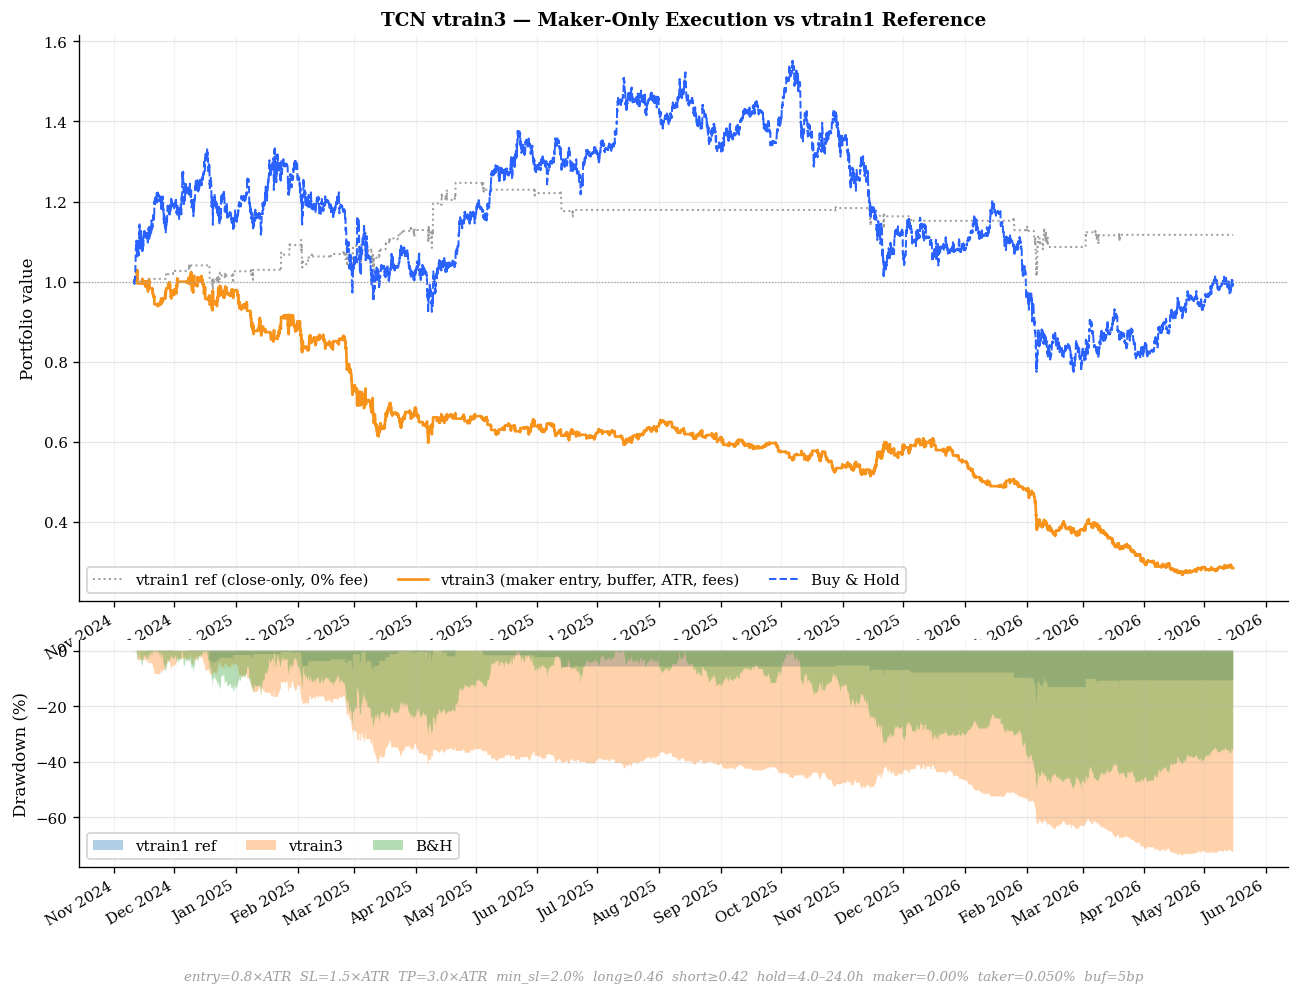

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios':[3,1.2],'hspace':0.10})
ax=axes[0]
ax.plot(test_index_v, eq_v1ref, color=GREY,   lw=1.2, ls=':', label='v1 ref (close-only, 0% fee)')
ax.plot(test_index_v, eq_v3,    color=ACCENT, lw=1.6,         label='v3 (maker entry, buffer, ATR, fees)')
ax.plot(test_index_v, test_bh,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value')
ax.set_title('TCN v3 — Maker-Only Execution vs v1 Reference', fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax=axes[1]
for eq,idx,color,lbl in [
    (eq_v1ref, test_index_v, GREY,   'v1 ref'),
    (eq_v3,    test_index_v, ACCENT, 'v3'),
    (test_bh,  test_index_v, BLUE,   'B&H'),
]:
    pk=np.maximum.accumulate(eq)
    ax.fill_between(idx,(eq-pk)/(pk+1e-12)*100,0,alpha=0.35,label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'entry={best_params["entry_atr_mult"]}×ATR  SL={best_params["sl_atr_multiplier"]}×ATR  '
    f'TP={best_params["tp_atr_multiplier"]}×ATR  min_sl={best_params["min_sl"]*100:.1f}%  '
    f'long≥{best_params["long_threshold"]}  short≥{best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'maker={MAKER_FEE*100:.2f}%  taker={TAKER_FEE*100:.3f}%  buf={BUFFER*1e4:.0f}bp',
    ha='center', fontsize=8, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'tcn_backtest_results_v3.png'); plt.show()

In [16]:
if not results_df.empty:
    out_csv = MODELS_DIR / 'tcn_grid_results_v3.csv'
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    def _s(eq): r=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    def _d(eq): pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

    out = {
        'version': 'v3',
        'changes_vs_v2': [
            'Execution: ATR SL/TP instead of TBM barriers (fewer, wider trades)',
            'Maker-only pullback entry at Close - entry_atr_mult*ATR',
            f'Penetration buffer {BUFFER*1e4:.0f}bp for FIFO fill guarantee',
            f'Asymmetric fees: Maker={MAKER_FEE*100:.2f}% (entries+TP) / Taker={TAKER_FEE*100:.3f}% (SL+time)',
            f'Funding drag: {FUNDING_RATE_H*100:.5f}%/h × {LEVERAGE} leverage',
            'No WFO: 5-ep warm-start proven to destabilize TCN (v2 -88%)',
        ],
        'maker_fee': MAKER_FEE, 'taker_fee': TAKER_FEE,
        'leverage': LEVERAGE, 'buffer': BUFFER, 'funding_rate_h': FUNDING_RATE_H,
        'selection_method': 'purged_kfold_fold_specific_val',
        'params': best_params,
        'oos_kfold': {
            'sharpe':       round(float(best['sharpe']), 4),
            'total_return': round(float(best['total_return']), 4),
            'max_dd':       round(float(best['max_dd']), 4),
            'n_trades':     int(best['n_trades']),
            'fill_rate':    round(float(best['fill_rate']), 4),
        },
        'test_static': {
            'sharpe':       round(_s(eq_v3), 4),
            'total_return': round(float(eq_v3[-1]-1), 4),
            'max_dd':       round(_d(eq_v3), 4),
            'n_trades':     int(len(tdf_v3)),
            'fill_rate':    round(tdf_v3.attrs.get('n_fills',0)/max(tdf_v3.attrs.get('n_signals',1),1), 4),
        },
    }

    out_json = MODELS_DIR / 'tcn_best_trading_params_v3.json'
    with open(out_json, 'w') as f: json.dump(out, f, indent=2)
    print(f'Saved: {out_json}')
    print()
    print(json.dumps(out, indent=2))

Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_grid_results_vtrain3.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_best_trading_params_vtrain3.json

{
  "version": "vtrain3",
  "changes_vs_vtrain2": [
    "Execution: ATR SL/TP instead of TBM barriers (fewer, wider trades)",
    "Maker-only pullback entry at Close - entry_atr_mult*ATR",
    "Penetration buffer 5bp for FIFO fill guarantee",
    "Asymmetric fees: Maker=0.00% (entries+TP) / Taker=0.050% (SL+time)",
    "Funding drag: 0.00077%/h \u00d7 1.0 leverage",
    "No WFO: 5-ep warm-start proven to destabilize TCN (vtrain2 -88%)"
  ],
  "maker_fee": 0.0,
  "taker_fee": 0.0005,
  "leverage": 1.0,
  "buffer": 0.0005,
  "funding_rate_h": 7.7e-06,
  "selection_method": "purged_kfold_fold_specific_val",
  "params": {
    "long_threshold": 0.46,
    "short_threshold": 0.42,
    "entry_atr_mult": 0.8,
    "sl_atr_multiplier": 1.5,
    "tp_atr_multipl